In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
df = pd.read_csv('/content/survey_results_public.csv')

In [56]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [57]:
df.shape

(65437, 114)

In [58]:
df.columns.tolist()

['ResponseId',
 'MainBranch',
 'Age',
 'Employment',
 'RemoteWork',
 'Check',
 'CodingActivities',
 'EdLevel',
 'LearnCode',
 'LearnCodeOnline',
 'TechDoc',
 'YearsCode',
 'YearsCodePro',
 'DevType',
 'OrgSize',
 'PurchaseInfluence',
 'BuyNewTool',
 'BuildvsBuy',
 'TechEndorse',
 'Country',
 'Currency',
 'CompTotal',
 'LanguageHaveWorkedWith',
 'LanguageWantToWorkWith',
 'LanguageAdmired',
 'DatabaseHaveWorkedWith',
 'DatabaseWantToWorkWith',
 'DatabaseAdmired',
 'PlatformHaveWorkedWith',
 'PlatformWantToWorkWith',
 'PlatformAdmired',
 'WebframeHaveWorkedWith',
 'WebframeWantToWorkWith',
 'WebframeAdmired',
 'EmbeddedHaveWorkedWith',
 'EmbeddedWantToWorkWith',
 'EmbeddedAdmired',
 'MiscTechHaveWorkedWith',
 'MiscTechWantToWorkWith',
 'MiscTechAdmired',
 'ToolsTechHaveWorkedWith',
 'ToolsTechWantToWorkWith',
 'ToolsTechAdmired',
 'NEWCollabToolsHaveWorkedWith',
 'NEWCollabToolsWantToWorkWith',
 'NEWCollabToolsAdmired',
 'OpSysPersonal use',
 'OpSysProfessional use',
 'OfficeStackAsyncHa

In [59]:
columns = [
    'Country',
    'ConvertedCompYearly',
    'RemoteWork',
    'YearsCodePro',
    'Employment',
    'LanguageHaveWorkedWith',
    'AISelect'
]

df = df[columns]

In [60]:
df.isnull().sum()

,0
Country,6507
ConvertedCompYearly,42002
RemoteWork,10631
YearsCodePro,13827
Employment,0
LanguageHaveWorkedWith,5692
AISelect,4530


In [61]:
df = df.dropna(subset=['ConvertedCompYearly'])

In [62]:
df = df[
    (df['ConvertedCompYearly'] > 1000) &
    (df['ConvertedCompYearly'] < 300000)
]

In [63]:
latam = [
    'Argentina',
    'Brazil',
    'Chile',
    'Colombia',
    'Mexico',
    'Peru',
    'Uruguay'
]

df = df[df['Country'].isin(latam)]

In [64]:
df.shape

(1153, 7)

In [65]:
def salary_category(x):
    if x < 20000:
        return 'Low'
    elif x < 60000:
        return 'Medium'
    else:
        return 'High'

df['SalaryCategory'] = df['ConvertedCompYearly'].apply(salary_category)

In [66]:
def experience_group(x):
    try:
        x = float(x)
        if x < 3:
            return 'Junior'
        elif x < 7:
            return 'Semi Senior'
        else:
            return 'Senior'
    except:
        return 'Unknown'

df['ExperienceLevel'] = df['YearsCodePro'].apply(experience_group)

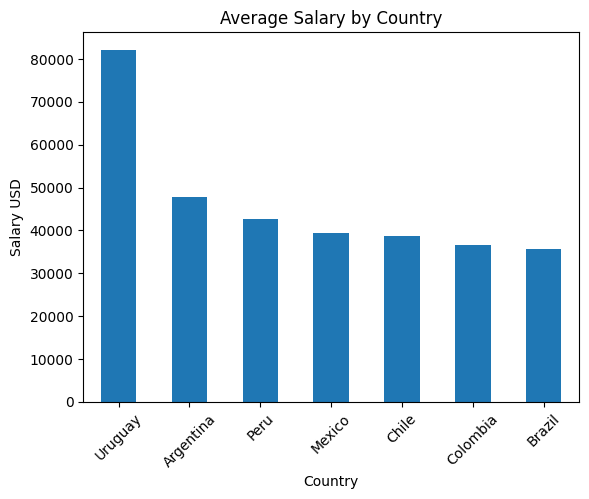

In [67]:
salary_country = (
    df.groupby('Country')['ConvertedCompYearly']
    .mean()
    .sort_values(ascending=False)
)

salary_country.plot(kind='bar')

plt.title('Average Salary by Country')
plt.ylabel('Salary USD')
plt.xticks(rotation=45)

plt.show()

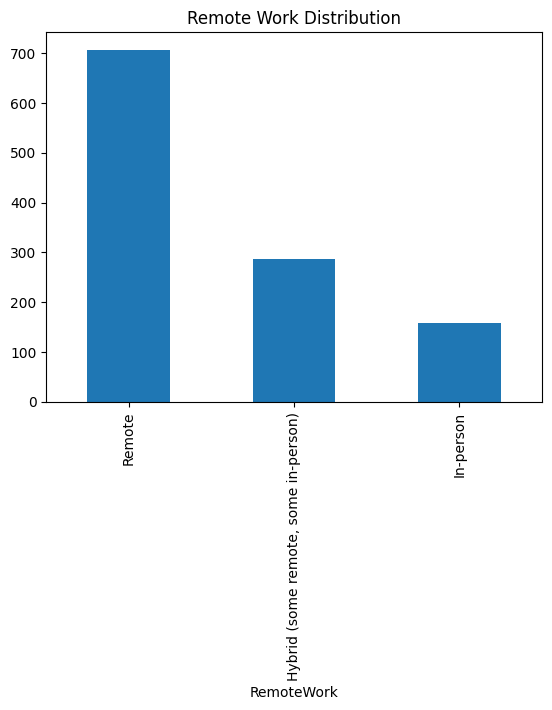

In [68]:
remote_counts = df['RemoteWork'].value_counts()

remote_counts.plot(kind='bar')

plt.title('Remote Work Distribution')

plt.show()


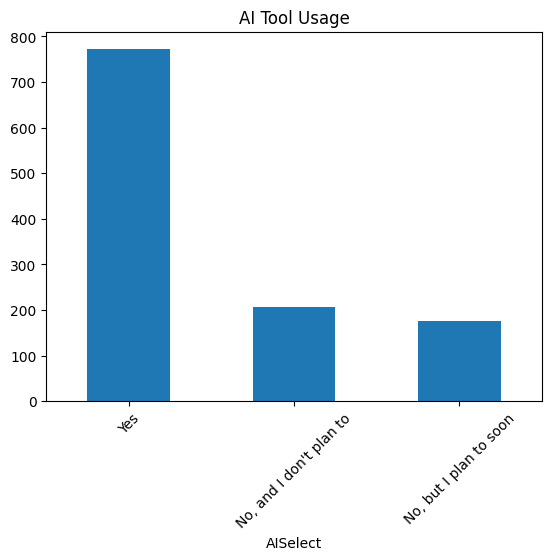

In [69]:
ai_usage = df['AISelect'].value_counts().head(10)

ai_usage.plot(kind='bar')

plt.title('AI Tool Usage')

plt.xticks(rotation=45)

plt.show()

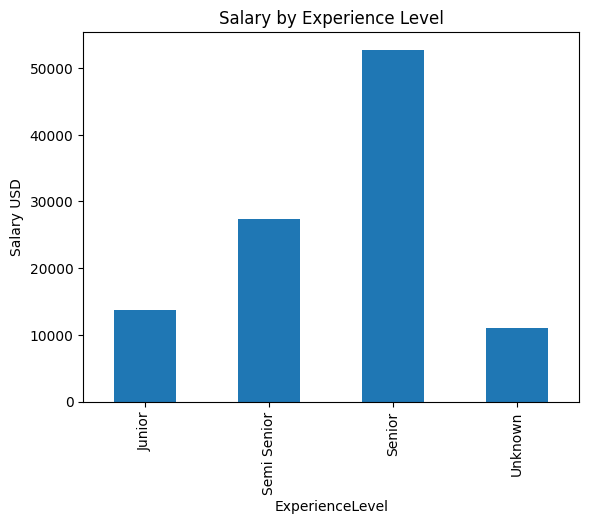

In [70]:
salary_exp = (
    df.groupby('ExperienceLevel')['ConvertedCompYearly']
    .mean()
)

salary_exp.plot(kind='bar')

plt.title('Salary by Experience Level')

plt.ylabel('Salary USD')

plt.show()

In [71]:
languages = df['LanguageHaveWorkedWith'].dropna()

all_languages = []

for item in languages:
    split_langs = item.split(';')

    for lang in split_langs:
        all_languages.append(lang)

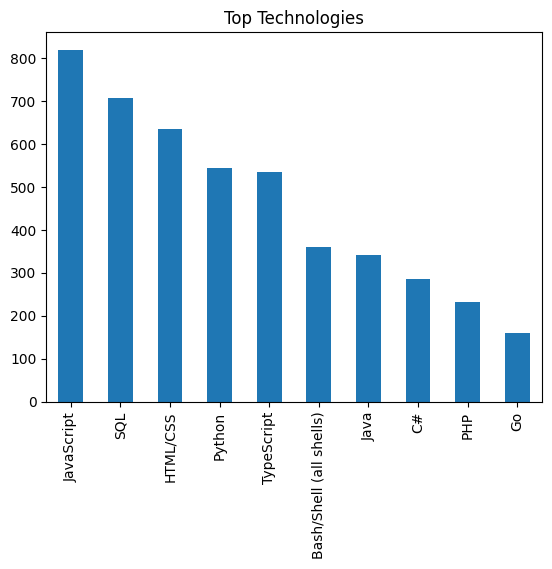

In [72]:
lang_series = pd.Series(all_languages)

top_languages = lang_series.value_counts().head(10)

top_languages.plot(kind='bar')

plt.title('Top Technologies')

plt.show()

In [73]:
df.to_csv('cleaned_tech_data.csv', index=False)

In [74]:
import pandas as pd

In [75]:
df = pd.read_csv('survey_results_public.csv')

In [76]:
languages = df['LanguageHaveWorkedWith'].dropna()

all_languages = []

for item in languages:
    split_langs = item.split(';')

    for lang in split_langs:
        all_languages.append(lang)

lang_df = pd.DataFrame(all_languages, columns=['Language'])

In [77]:
top_languages = (
    lang_df['Language']
    .value_counts()
    .reset_index()
)

top_languages.columns = ['Language', 'Count']

In [78]:
top_languages.to_csv('top_languages.csv', index=False)

In [79]:
def experience_group(x):
    try:
        x = float(x)

        if x < 3:
            return 'Junior'
        elif x < 7:
            return 'Semi Senior'
        else:
            return 'Senior'

    except:
        return 'Unknown'

df['ExperienceLevel'] = df['YearsCodePro'].apply(experience_group)

In [80]:
ai_exp = (
    df.groupby('ExperienceLevel')['AISelect']
    .count()
    .reset_index()
)

ai_exp.columns = ['ExperienceLevel', 'AIUsers']

In [81]:
ai_exp.to_csv('ai_by_experience.csv', index=False)